In [2]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\MedVision-AI


# Section 1 – Create Image Path List

Collect every image path from the dataset.

In [4]:
from pathlib import Path

DATASET_PATH = Path(r"C:\MedVision-AI\dataset\chest_xray")

from app.preprocessing.dataset import collect_image_paths

image_paths, labels = collect_image_paths(
    dataset_path=DATASET_PATH,
    split="train",
)

In [5]:
print(f"Total Images : {len(image_paths)}")

print(image_paths[:5])

print(labels[:5])

Total Images : 5216
[WindowsPath('C:/MedVision-AI/dataset/chest_xray/train/NORMAL/IM-0115-0001.jpeg'), WindowsPath('C:/MedVision-AI/dataset/chest_xray/train/NORMAL/IM-0117-0001.jpeg'), WindowsPath('C:/MedVision-AI/dataset/chest_xray/train/NORMAL/IM-0119-0001.jpeg'), WindowsPath('C:/MedVision-AI/dataset/chest_xray/train/NORMAL/IM-0122-0001.jpeg'), WindowsPath('C:/MedVision-AI/dataset/chest_xray/train/NORMAL/IM-0125-0001.jpeg')]
['NORMAL', 'NORMAL', 'NORMAL', 'NORMAL', 'NORMAL']


# Section 2 – Encode Labels

Convert text labels into integers.

In [6]:
label_map = {
    "NORMAL": 0,
    "PNEUMONIA": 1,
}

encoded_labels = [label_map[label] for label in labels]

In [7]:
print(encoded_labels[:10])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# Section 3 – Create DataFrame

Organize metadata.

In [8]:
import pandas as pd

dataset_df = pd.DataFrame(
    {
        "Image_Path": image_paths,
        "Label": labels,
        "Encoded_Label": encoded_labels,
    }
)

dataset_df.head()

,Image_Path,Label,Encoded_Label
0,C:\MedVision-AI\dataset\chest_xray\train\NORMA...,NORMAL,0
1,C:\MedVision-AI\dataset\chest_xray\train\NORMA...,NORMAL,0
2,C:\MedVision-AI\dataset\chest_xray\train\NORMA...,NORMAL,0
3,C:\MedVision-AI\dataset\chest_xray\train\NORMA...,NORMAL,0
4,C:\MedVision-AI\dataset\chest_xray\train\NORMA...,NORMAL,0


# Section 4 – Split Dataset

We already have separate train, val, and test folders. In production, use those directly rather than randomly splitting again.

In [9]:
train_df = dataset_df.copy()

# Section 5 – Create Dataset Object

In [10]:
from app.preprocessing.dataset import ChestXRayDataset
from app.preprocessing.transforms import train_transform

train_dataset = ChestXRayDataset(
    image_paths=train_df["Image_Path"].tolist(),
    labels=train_df["Encoded_Label"].tolist(),
    transform=train_transform,
)

In [11]:
print(len(train_dataset))

5216


# Retrieve One Sample

In [12]:
image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0


# Section 6 – Create DataLoader

The Dataset knows how to read one sample.

The DataLoader knows how to read many samples efficiently

In [3]:
import torch
from pathlib import Path

from app.preprocessing.dataset import get_dataloaders
from app.preprocessing.transforms import (
    train_transform,
    val_transform,
)

DATASET_PATH = Path(r"C:\MedVision-AI\dataset\chest_xray")

BATCH_SIZE = 32

train_loader, val_loader, test_loader = get_dataloaders(
    dataset_path=DATASET_PATH,
    train_transform=train_transform,
    val_transform=val_transform,
    batch_size=BATCH_SIZE,
)

In [ ]:
print(len(train_loader))        #5216 / 32 = 163 batches

163


# Section 7 – Inspect One Batch

In [ ]:
images, labels = next(iter(train_loader))

In [ ]:
print(images.shape)

print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Interpretation

One training iteration receives:

32 images
32 labels

instead of all 5216 images.

# Section 8 – Visualize a Mini-batch

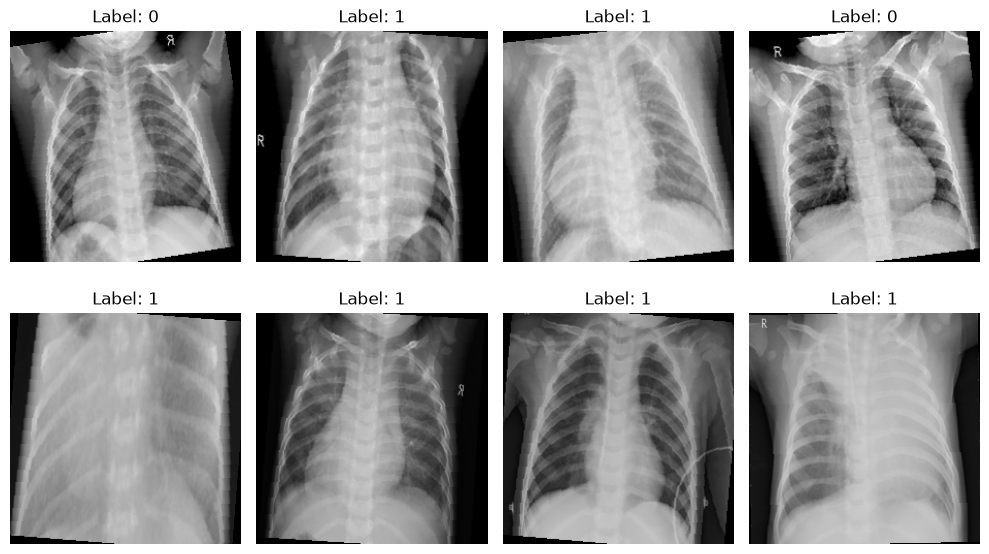

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(2,4, figsize=(10,6))

for i, ax in enumerate(axes.flatten()):

    img = images[i] * std + mean
    img = img.permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Section 9 – Verify Tensor Shapes

In [ ]:
print("Batch Shape :", images.shape)
print("Data Type   :", images.dtype)
print("Device      :", images.device)
print("Min Value   :", images.min().item())
print("Max Value   :", images.max().item())

Batch Shape : torch.Size([32, 3, 224, 224])
Data Type   : torch.float32
Device      : cpu
Min Value   : -2.1179039478302
Max Value   : 2.6225709915161133


# Section 10 – Pipeline Summary


Dataset Folder
        │
        ▼
Image Paths
        │
        ▼
Labels
        │
        ▼
Encoded Labels
        │
        ▼
ChestXRayDataset
        │
        ▼
DataLoader
        │
        ▼
Mini-batches
        │
        ▼
✅ Ready for EfficientNet Training